# 03 — Backtest Performance Evaluation

**Purpose**: Measure prediction quality using the deterministic backtesting engine.

Uses `prediction_agent.backtest.backtest.run_backtest()` — no LLM.

**Sections**:
1. Full-period backtest summary
2. Rolling window backtest (7d, 30d)
3. Brier score over time
4. Threshold sweep curve
5. Simulated P&L curve
6. Calibration curve
7. Tool marginal contribution ranking

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from config import OUTPUTS_DIR, SQLITE_DB_FILE
from prediction_agent.backtest.backtest import run_backtest, BacktestReport, print_report
from prediction_agent.storage.sqlite_store import SQLiteStore

SNAP_FILE = OUTPUTS_DIR / 'market_snapshots.jsonl'
store = SQLiteStore()

if not SNAP_FILE.exists() or SNAP_FILE.stat().st_size == 0:
    print('⚠ No snapshot data found. Run the live loop first.')
else:
    # Count rows
    with open(SNAP_FILE) as f:
        n = sum(1 for l in f if l.strip())
    print(f'Snapshot file: {SNAP_FILE}')
    print(f'Rows available: {n}')

Snapshot file: C:\Users\srfer\Desktop\Kalshi_Agent\Kalshi_Agent\.claude\worktrees\adoring-tharp\outputs\market_snapshots.jsonl
Rows available: 536


## 1. Full-Period Backtest Summary

In [2]:
if SNAP_FILE.exists() and SNAP_FILE.stat().st_size > 0:
    report = run_backtest(
        snapshot_file=SNAP_FILE,
        formula_preset='equal_weight',
        threshold=0.55,
        verbose=False,
    )
    print_report(report)
else:
    print('No data available for backtest.')


BACKTEST REPORT
Snapshot file:      C:\Users\srfer\Desktop\Kalshi_Agent\Kalshi_Agent\.claude\worktrees\adoring-tharp\outputs\market_snapshots.jsonl
Formula preset:     equal_weight
Market filter:      (none)
Run timestamp:      2026-02-18T00:58:24.524549+00:00

Total events:       536
Events skipped:     0
Bets triggered:     0

Accuracy:           0.00%
Bet precision:      0.00%
Bet recall:         0.00%
Brier score:        0.0386  (lower = better)
Avg score delta:    0.0992
Simulated P&L:      $0.00

Tool contributions:
  mock_price_signal               selected= 536  avg_output=0.0366  total_contrib=3.2700
  mock_random_context             selected= 536  avg_output=0.4736  total_contrib=42.3101
  snapshot_volatility_tool        selected= 536  avg_output=0.0000  total_contrib=0.0000
  spread_compression_tool         selected= 536  avg_output=0.0000  total_contrib=0.0000
  price_jump_detector_tool        selected= 536  avg_output=0.0000  total_contrib=0.0000
  liquidity_spike_tool   

## 2. Threshold Sweep Curve

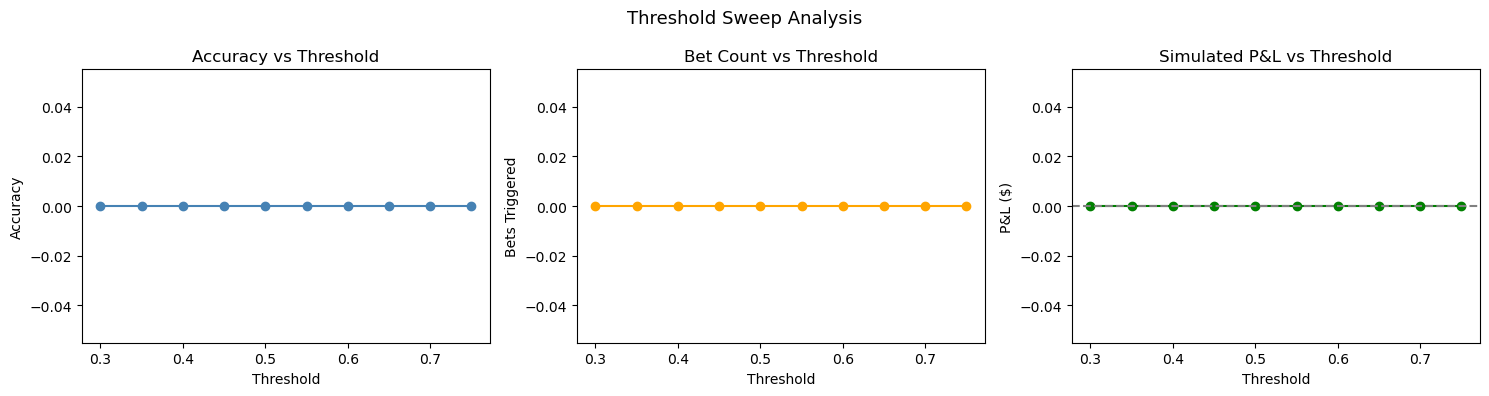


Optimal thresholds:
  Best accuracy: threshold=0.3  accuracy=0.00%
  Best P&L:      threshold=0.3  profit=$0.00


In [3]:
if SNAP_FILE.exists() and SNAP_FILE.stat().st_size > 0:
    thresholds = [round(t, 2) for t in np.arange(0.30, 0.80, 0.05)]
    results = []
    for t in thresholds:
        r = run_backtest(snapshot_file=SNAP_FILE, threshold=t, verbose=False)
        results.append({
            'threshold': t,
            'bets': r.bets_triggered,
            'accuracy': r.accuracy,
            'brier': r.brier_score,
            'profit': r.profit_simulation,
        })
    sweep_df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(sweep_df['threshold'], sweep_df['accuracy'], 'o-', color='steelblue')
    axes[0].set_title('Accuracy vs Threshold')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Accuracy')

    axes[1].plot(sweep_df['threshold'], sweep_df['bets'], 'o-', color='orange')
    axes[1].set_title('Bet Count vs Threshold')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Bets Triggered')

    axes[2].plot(sweep_df['threshold'], sweep_df['profit'], 'o-', color='green')
    axes[2].axhline(0, color='gray', linestyle='--')
    axes[2].set_title('Simulated P&L vs Threshold')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('P&L ($)')

    plt.suptitle('Threshold Sweep Analysis', fontsize=13)
    plt.tight_layout()
    plt.show()

    print('\nOptimal thresholds:')
    best_acc = sweep_df.loc[sweep_df['accuracy'].idxmax()]
    best_pnl = sweep_df.loc[sweep_df['profit'].idxmax()]
    print(f'  Best accuracy: threshold={best_acc["threshold"]}  accuracy={best_acc["accuracy"]:.2%}')
    print(f'  Best P&L:      threshold={best_pnl["threshold"]}  profit=${best_pnl["profit"]:.2f}')

## 3. Simulated P&L Curve (Cumulative)

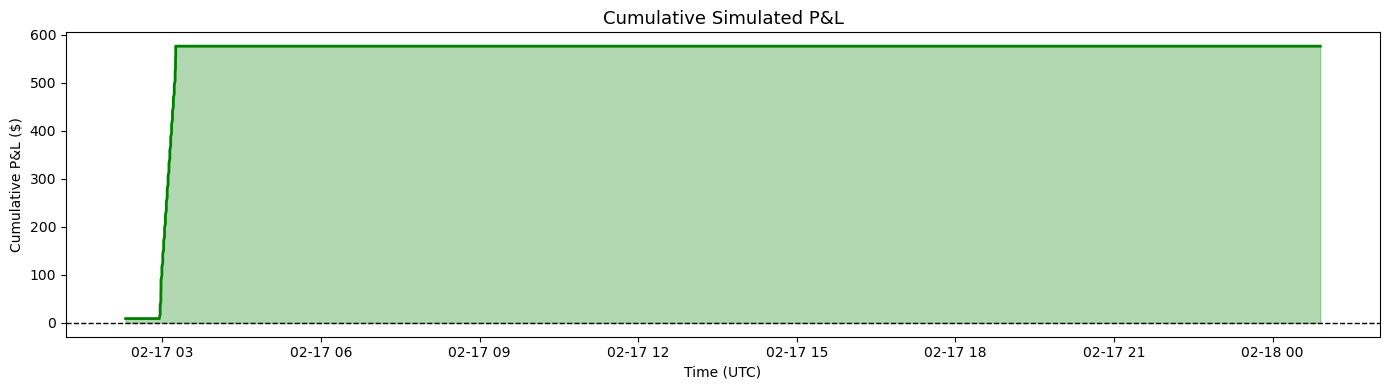

Total bets: 64
Final P&L:  $576.00


In [4]:
if SQLITE_DB_FILE.exists():
    runs_df = pd.DataFrame(store.query(
        "SELECT timestamp, score, threshold, bet_triggered FROM runs ORDER BY timestamp"
    ))
    runs_df['timestamp'] = pd.to_datetime(runs_df['timestamp'], utc=True, errors='coerce')

    if len(runs_df) > 5:
        # Proxy P&L: if bet triggered and score >= 0.5 → +9 (10 to win 9), else -10
        runs_df['pnl'] = runs_df.apply(
            lambda r: 9.0 if r['bet_triggered'] and r['score'] >= 0.5
                      else (-10.0 if r['bet_triggered'] else 0.0),
            axis=1
        )
        runs_df['cum_pnl'] = runs_df['pnl'].cumsum()

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(runs_df['timestamp'], runs_df['cum_pnl'], linewidth=2, color='green')
        ax.fill_between(
            runs_df['timestamp'], runs_df['cum_pnl'], 0,
            where=(runs_df['cum_pnl'] >= 0), alpha=0.3, color='green'
        )
        ax.fill_between(
            runs_df['timestamp'], runs_df['cum_pnl'], 0,
            where=(runs_df['cum_pnl'] < 0), alpha=0.3, color='red'
        )
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title('Cumulative Simulated P&L', fontsize=13)
        ax.set_xlabel('Time (UTC)')
        ax.set_ylabel('Cumulative P&L ($)')
        plt.tight_layout()
        plt.show()

        print(f'Total bets: {runs_df["bet_triggered"].sum()}')
        print(f'Final P&L:  ${runs_df["cum_pnl"].iloc[-1]:.2f}')
    else:
        print('Need more runs for P&L curve.')

## 4. Calibration Curve (Score vs Realized Frequency)

In [5]:
if SQLITE_DB_FILE.exists():
    cal_df = pd.DataFrame(store.query(
        "SELECT score, outcome FROM runs WHERE outcome IS NOT NULL"
    ))

    if len(cal_df) >= 20:
        cal_df['bin'] = pd.cut(cal_df['score'], bins=10, labels=False)
        calibration = cal_df.groupby('bin').agg(
            mean_score=('score', 'mean'),
            mean_outcome=('outcome', 'mean'),
            count=('outcome', 'count')
        ).dropna()

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.5)
        scatter = ax.scatter(
            calibration['mean_score'], calibration['mean_outcome'],
            s=calibration['count']*10, alpha=0.7, c='steelblue', zorder=5
        )
        ax.set_xlabel('Mean Predicted Score')
        ax.set_ylabel('Realized Outcome Frequency')
        ax.set_title('Calibration Curve\n(bubble size = sample count)', fontsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f'Need ≥20 runs with known outcomes for calibration (have {len(cal_df)}).')
        print('Outcomes are populated when markets resolve.')

Need ≥20 runs with known outcomes for calibration (have 0).
Outcomes are populated when markets resolve.


## 5. Tool Marginal Contribution Ranking

Tool Marginal Contributions (average weighted contribution to final score):
                 tool_id   n  avg_output  avg_contribution  avg_weight
    liquidity_spike_tool 558  423.411290         70.568550    0.166667
snapshot_volatility_tool 559  394.456403         65.743108    0.167263
     mock_random_context 558    0.469975          0.078329    0.166667
       mock_price_signal 558    0.041326          0.006888    0.166667
 spread_compression_tool 559    0.030376          0.005420    0.167263
price_jump_detector_tool 558    0.000000          0.000000    0.166667


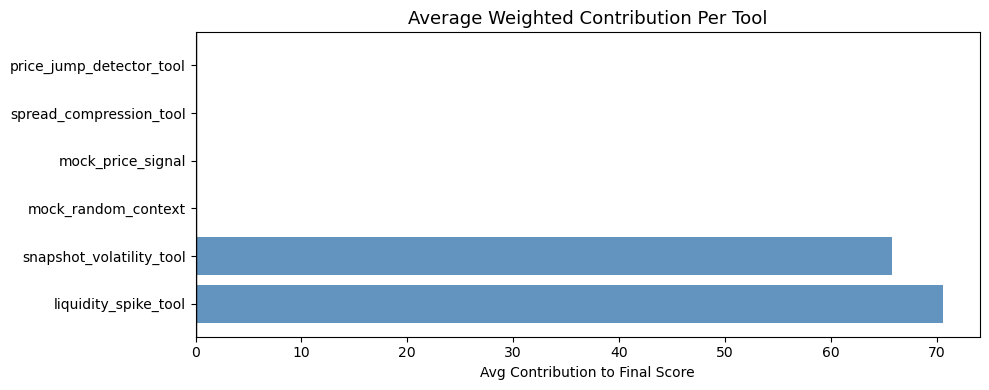

In [6]:
if SQLITE_DB_FILE.exists():
    contribs = pd.DataFrame(store.query("""
        SELECT tool_id,
               COUNT(*) AS n,
               AVG(output_mean) AS avg_output,
               AVG(contribution) AS avg_contribution,
               AVG(weight) AS avg_weight
        FROM tool_outputs
        GROUP BY tool_id
        ORDER BY avg_contribution DESC
    """))

    if not contribs.empty:
        print('Tool Marginal Contributions (average weighted contribution to final score):')
        print(contribs.to_string(index=False))

        fig, ax = plt.subplots(figsize=(10, 4))
        colors = ['steelblue' if c >= 0 else 'salmon' for c in contribs['avg_contribution']]
        ax.barh(contribs['tool_id'], contribs['avg_contribution'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title('Average Weighted Contribution Per Tool', fontsize=13)
        ax.set_xlabel('Avg Contribution to Final Score')
        plt.tight_layout()
        plt.show()
    else:
        print('No tool_outputs in SQLite yet.')